/tmp/ipykernel_749797/3649851481.py:135: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(disease_keys))
/tmp/ipykernel_749797/3649851481.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.96])


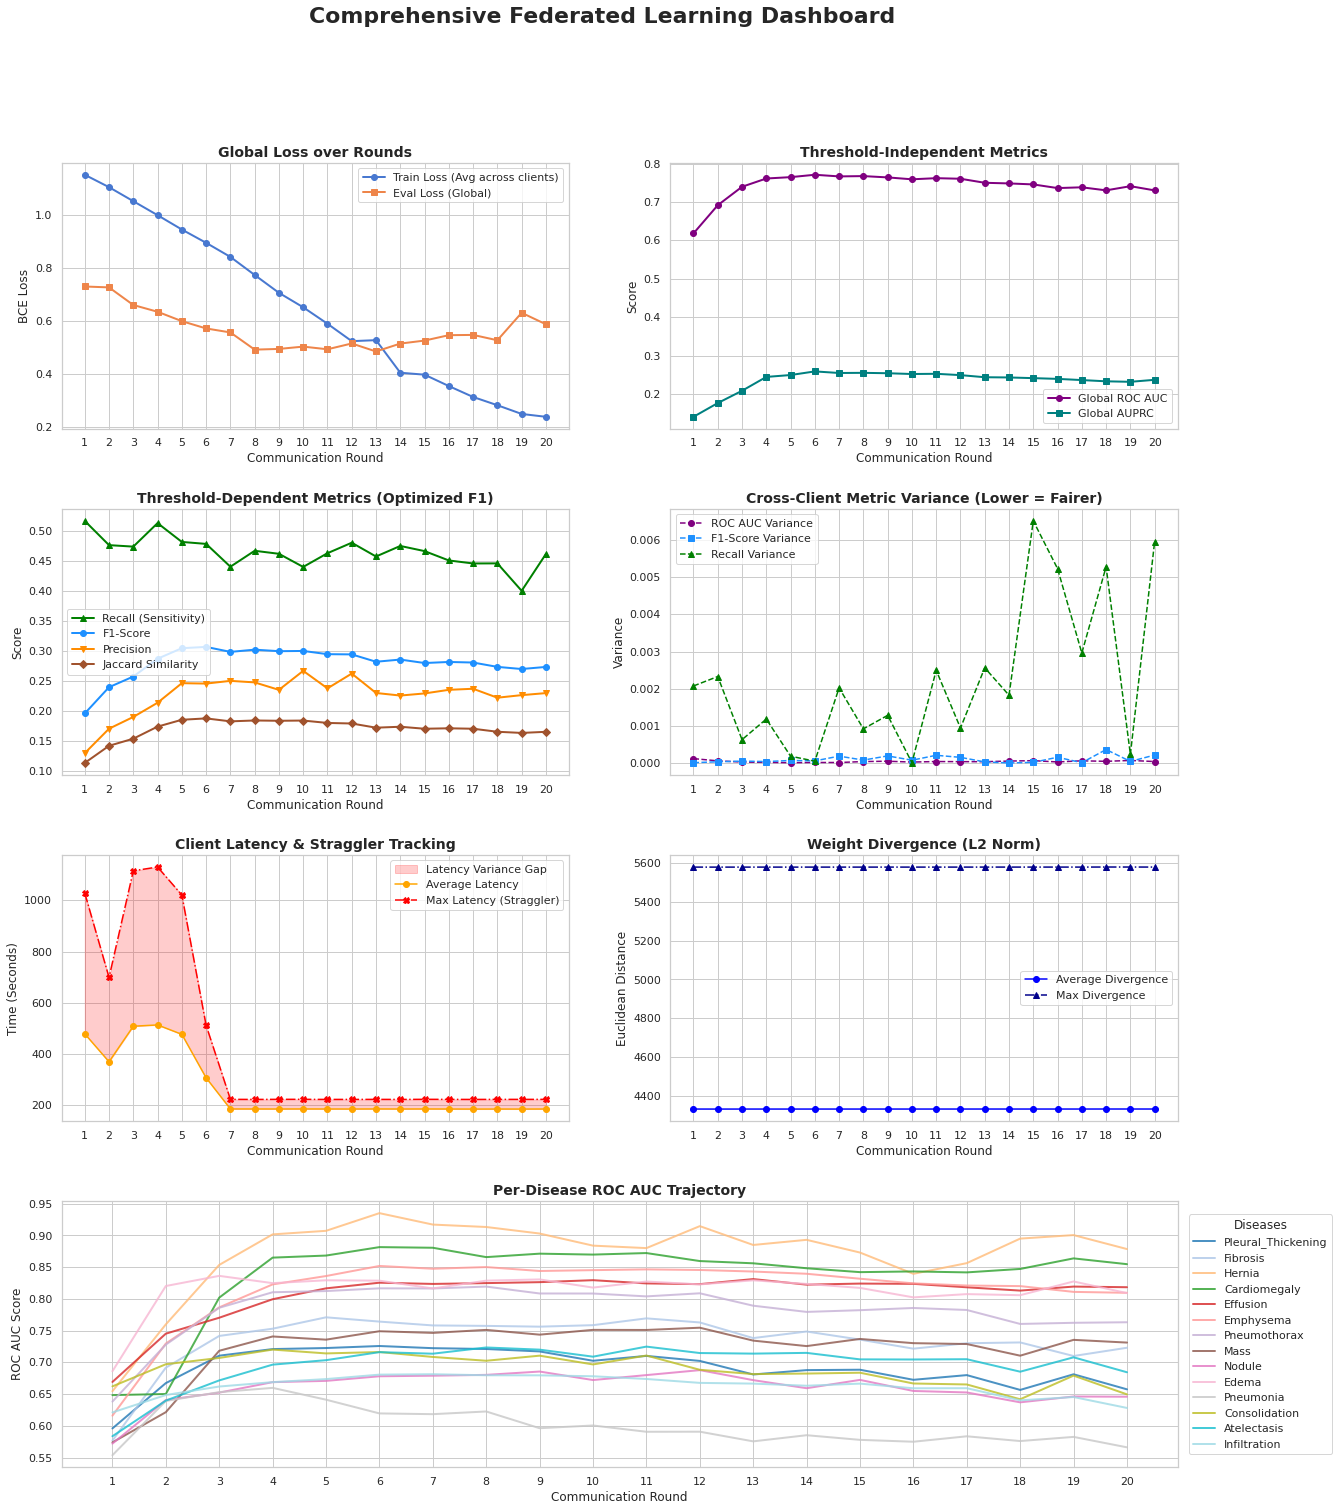

------------------------------------------------------------
FINAL ROUND SUMMARY:
------------------------------------------------------------
Final Eval Loss:      0.5873
Final Global AUC:     0.7301
Final Global AUPRC:   0.2370
Final Global F1:      0.2738
Final Global Recall:  0.4623
Final Global Prec:    0.2301
------------------------------------------------------------
Top 3 Performing Diseases (AUC):
 - Hernia              : 0.8786
 - Cardiomegaly        : 0.8548
 - Effusion            : 0.8185

Bottom 3 Performing Diseases (AUC):
 - Nodule              : 0.6460
 - Infiltration        : 0.6283
 - Pneumonia           : 0.5663
------------------------------------------------------------


In [3]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.gridspec as gridspec

sns.set_theme(style="whitegrid", palette="muted")

def load_and_extract(filepath):
    """Loads JSON and provides a helper to extract X (rounds) and Y (values)."""
    with open(filepath, 'r') as f:
        data = json.load(f)
        
    def extract_xy(metric_data):
        if not metric_data: return [], []
        rounds = [item[0] for item in metric_data]
        values = [item[1] for item in metric_data]
        return rounds, values
        
    return data, extract_xy

def plot_comprehensive_dashboard(filepath="federated_metrics.json"):
    data, get_xy = load_and_extract(filepath)
    
    # Create a 4x2 grid layout
    fig = plt.figure(figsize=(20, 24))
    fig.suptitle("Comprehensive Federated Learning Dashboard", fontsize=22, y=0.97, fontweight='bold')
    gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.3)

    # ==========================================
    # 1. Loss Curve (Train vs Eval)
    # ==========================================
    ax1 = fig.add_subplot(gs[0, 0])
    train_x, train_y = get_xy(data['metrics_distributed_fit']['avg_train_loss'])
    eval_x, eval_y = get_xy(data['losses_distributed'])
    
    ax1.plot(train_x, train_y, label='Train Loss (Avg across clients)', marker='o', linewidth=2)
    ax1.plot(eval_x, eval_y, label='Eval Loss (Global)', marker='s', linewidth=2)
    ax1.set_title('Global Loss over Rounds', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Communication Round')
    ax1.set_ylabel('BCE Loss')
    ax1.set_xticks(train_x)
    ax1.legend()

    # ==========================================
    # 2. Global Probability Metrics (AUC & AUPRC)
    # ==========================================
    ax2 = fig.add_subplot(gs[0, 1])
    auc_x, auc_y = get_xy(data['metrics_distributed']['global_auc'])
    auprc_x, auprc_y = get_xy(data['metrics_distributed']['global_auprc'])
    
    ax2.plot(auc_x, auc_y, label='Global ROC AUC', marker='o', color='purple', linewidth=2)
    ax2.plot(auprc_x, auprc_y, label='Global AUPRC', marker='s', color='teal', linewidth=2)
    ax2.set_title('Threshold-Independent Metrics', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Communication Round')
    ax2.set_ylabel('Score')
    ax2.set_xticks(auc_x)
    ax2.legend()

    # ==========================================
    # 3. Global Classification Metrics (F1, Prec, Rec, Jacc)
    # ==========================================
    ax3 = fig.add_subplot(gs[1, 0])
    f1_x, f1_y = get_xy(data['metrics_distributed']['global_f1'])
    rec_x, rec_y = get_xy(data['metrics_distributed']['global_recall'])
    prec_x, prec_y = get_xy(data['metrics_distributed']['global_precision'])
    jacc_x, jacc_y = get_xy(data['metrics_distributed']['global_jaccard'])
    
    ax3.plot(rec_x, rec_y, label='Recall (Sensitivity)', marker='^', color='green', linewidth=2)
    ax3.plot(f1_x, f1_y, label='F1-Score', marker='o', color='dodgerblue', linewidth=2)
    ax3.plot(prec_x, prec_y, label='Precision', marker='v', color='darkorange', linewidth=2)
    ax3.plot(jacc_x, jacc_y, label='Jaccard Similarity', marker='D', color='sienna', linewidth=2)
    
    ax3.set_title('Threshold-Dependent Metrics (Optimized F1)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Communication Round')
    ax3.set_ylabel('Score')
    ax3.set_xticks(f1_x)
    ax3.legend()

    # ==========================================
    # 4. Cross-Client Variance (Fairness)
    # ==========================================
    ax4 = fig.add_subplot(gs[1, 1])
    f1_var_x, f1_var_y = get_xy(data['metrics_distributed']['global_f1_variance'])
    auc_var_x, auc_var_y = get_xy(data['metrics_distributed']['global_auc_variance'])
    rec_var_x, rec_var_y = get_xy(data['metrics_distributed']['global_recall_variance'])
    
    ax4.plot(auc_var_x, auc_var_y, label='ROC AUC Variance', marker='o', color='purple', linestyle='--')
    ax4.plot(f1_var_x, f1_var_y, label='F1-Score Variance', marker='s', color='dodgerblue', linestyle='--')
    ax4.plot(rec_var_x, rec_var_y, label='Recall Variance', marker='^', color='green', linestyle='--')
    
    ax4.set_title('Cross-Client Metric Variance (Lower = Fairer)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Communication Round')
    ax4.set_ylabel('Variance')
    ax4.set_xticks(f1_var_x)
    ax4.legend()

    # ==========================================
    # 5. Straggler Analysis (Latency)
    # ==========================================
    ax5 = fig.add_subplot(gs[2, 0])
    avg_lat_x, avg_lat_y = get_xy(data['metrics_distributed_fit']['avg_latency'])
    max_lat_x, max_lat_y = get_xy(data['metrics_distributed_fit']['max_latency'])
    
    ax5.fill_between(avg_lat_x, avg_lat_y, max_lat_y, alpha=0.2, color='red', label='Latency Variance Gap')
    ax5.plot(avg_lat_x, avg_lat_y, label='Average Latency', marker='o', color='orange')
    ax5.plot(max_lat_x, max_lat_y, label='Max Latency (Straggler)', marker='X', color='red', linestyle='-.')
    ax5.set_title('Client Latency & Straggler Tracking', fontsize=14, fontweight='bold')
    ax5.set_xlabel('Communication Round')
    ax5.set_ylabel('Time (Seconds)')
    ax5.set_xticks(avg_lat_x)
    ax5.legend()

    # ==========================================
    # 6. Weight Divergence
    # ==========================================
    ax6 = fig.add_subplot(gs[2, 1])
    avg_div_x, avg_div_y = get_xy(data['metrics_distributed_fit']['avg_weight_divergence'])
    max_div_x, max_div_y = get_xy(data['metrics_distributed_fit']['max_weight_divergence'])
    
    ax6.plot(avg_div_x, avg_div_y, label='Average Divergence', marker='o', color='blue')
    ax6.plot(max_div_x, max_div_y, label='Max Divergence', marker='^', color='darkblue', linestyle='-.')
    ax6.set_title('Weight Divergence (L2 Norm)', fontsize=14, fontweight='bold')
    ax6.set_xlabel('Communication Round')
    ax6.set_ylabel('Euclidean Distance')
    ax6.set_xticks(avg_div_x)
    ax6.legend()

    # ==========================================
    # 7. Per-Disease AUC Trajectory
    # ==========================================
    ax7 = fig.add_subplot(gs[3, :]) # Span the entire bottom row
    disease_keys = [k for k in data['metrics_distributed'].keys() if k.startswith('auc_') and not k.endswith('_variance')]
    
    cmap = plt.cm.get_cmap('tab20', len(disease_keys))
    
    final_aucs = {}
    for i, key in enumerate(disease_keys):
        disease_name = key.replace('auc_', '')
        x, y = get_xy(data['metrics_distributed'][key])
        
        valid_y = [val for val in y if not np.isnan(val)]
        if valid_y:
            ax7.plot(x, y, label=disease_name, color=cmap(i), alpha=0.8, linewidth=2)
            final_aucs[disease_name] = valid_y[-1]
        else:
            final_aucs[disease_name] = float('nan')

    ax7.set_title('Per-Disease ROC AUC Trajectory', fontsize=14, fontweight='bold')
    ax7.set_xlabel('Communication Round')
    ax7.set_ylabel('ROC AUC Score')
    ax7.set_xticks(train_x)
    
    ax7.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), title="Diseases", borderaxespad=0.)

    plt.tight_layout(rect=[0, 0.02, 1, 0.96])
    plt.show()

    print("-" * 60)
    print("FINAL ROUND SUMMARY:")
    print("-" * 60)
    print(f"Final Eval Loss:      {eval_y[-1]:.4f}")
    print(f"Final Global AUC:     {auc_y[-1]:.4f}")
    print(f"Final Global AUPRC:   {auprc_y[-1]:.4f}")
    print(f"Final Global F1:      {f1_y[-1]:.4f}")
    print(f"Final Global Recall:  {rec_y[-1]:.4f}")
    print(f"Final Global Prec:    {prec_y[-1]:.4f}")
    print("-" * 60)
    print("Top 3 Performing Diseases (AUC):")
    
    valid_diseases = {k: v for k, v in final_aucs.items() if not np.isnan(v)}
    sorted_diseases = sorted(valid_diseases.items(), key=lambda item: item[1], reverse=True)
    
    for name, score in sorted_diseases[:3]:
        print(f" - {name.ljust(20)}: {score:.4f}")
        
    print("\nBottom 3 Performing Diseases (AUC):")
    for name, score in sorted_diseases[-3:]:
        print(f" - {name.ljust(20)}: {score:.4f}")
    print("-" * 60)

plot_comprehensive_dashboard("federated_metrics.json")